# Рынок поддержаных машин

## Импорт библиотек

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.metrics import mean_absolute_error, r2_score

# Необходимые библиотеки


# Загрузка данных рынка поддержаных машин

In [10]:
df = pd.read_csv('used_car_price_dataset_extended.csv')

print(f'Размеры таблицы: {df.shape[0]} машин и {df.shape[1]} параметров')

df['mileage_cat'] = df['mileage_kmpl'].apply(lambda x:
    'low' if x <= 10 
    else 'medium' if x <= 20 else 'high'
    )

# car_impact = df.groupby('mileage_cat')[['make_year', 'price_usd']].median()
car_impact = df.groupby('mileage_cat')['price_usd'].median()
print('\n Цены на автомобили ($) в зависимости от расхода топлива км/л:')
print(car_impact)

df.head(3)

# Чем больше расход топлива на километр тем выше цена

Размеры таблицы: 10000 машин и 12 параметров

 Цены на автомобили ($) в зависимости от расхода топлива км/л:
mileage_cat
high      7635.340
low       5969.525
medium    6698.270
Name: price_usd, dtype: float64


,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,price_usd,brand,transmission,color,service_history,accidents_reported,insurance_valid,mileage_cat
0,2001,8.17,4000,Petrol,4,8587.64,Chevrolet,Manual,White,NaN,0,No,low
1,2014,17.59,1500,Petrol,4,5943.50,Honda,Manual,Black,NaN,0,Yes,medium
2,2023,18.09,2500,Diesel,5,9273.58,BMW,Automatic,Black,Full,1,Yes,medium


# Масштабирование и кодировка данных

In [4]:
df = pd.get_dummies(df, drop_first=True)

X = df.drop('price_usd', axis=1)
y = df['price_usd']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

numeric_cols = ['make_year', 'engine_cc', 'owner_count', 'accidents_reported', 'mileage_kmpl']
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

X_train.head(3)

# Масштабируем числовые признаки, чтобы улучшить производительность модели KNN

,make_year,mileage_kmpl,engine_cc,owner_count,accidents_reported,fuel_type_Electric,fuel_type_Petrol,brand_Chevrolet,brand_Ford,brand_Honda,...,transmission_Manual,color_Blue,color_Gray,color_Red,color_Silver,color_White,service_history_Partial,insurance_valid_Yes,mileage_cat_low,mileage_cat_medium
9254,-0.860884,-1.644253,-0.379682,-0.705460,-0.703197,False,False,False,False,False,...,True,False,False,False,True,False,True,False,True,False
1561,-0.622453,-0.368146,-0.612288,-0.000793,-0.703197,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,True
1670,-0.503238,-1.482746,2.101455,-0.705460,-0.703197,False,False,False,True,False,...,True,False,True,False,False,False,False,False,False,True


# Поиск оптимального числа соседей (k)

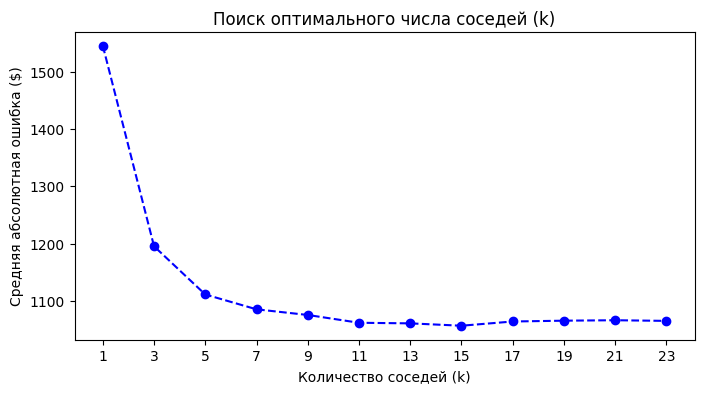

In [5]:
errors = []
k_values = range(1, 25, 2)

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors = k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    errors.append(mean_absolute_error(y_test, y_pred))
    
plt.figure(figsize=(8,4))
plt.plot(k_values, errors, marker='o', linestyle='dashed', color='blue')
plt.title('Поиск оптимального числа соседей (k)')
plt.xlabel('Количество соседей (k)')
plt.ylabel('Средняя абсолютная ошибка ($)')
plt.xticks(k_values)

plt.show()

# Оптимальное значение k - 7

# Исследование метрик расстяния Минковского

In [6]:
best_k = 7

# обучаем модель с Евклидовой метрикой (p=2)
knn_euclidean = KNeighborsRegressor(n_neighbors=best_k, p=2)
knn_euclidean.fit(X_train, y_train)
y_pred_euclidean = knn_euclidean.predict(X_test)

# обучаем модель с Манхэттенской метрикой (p=1)
knn_manhattan = KNeighborsRegressor(n_neighbors=best_k, p=1)
knn_manhattan.fit(X_train, y_train)
y_pred_manhattan = knn_manhattan.predict(X_test)

print('=== Сравнение метрик расстояния ===')
print(f'Евклидово расстояние (p=2): MAE = ${mean_absolute_error(y_test, y_pred_euclidean):.2f} | R2 = {r2_score(y_test, y_pred_euclidean):.2f}')
print(f'Манхэттенское расстояние (p=1): MAE = ${mean_absolute_error(y_test, y_pred_manhattan):.2f} | R2 = {r2_score(y_test, y_pred_manhattan):.2f}')

# Евклидово расстояние выдаёт лучшие результаты R2 и MAE, 
# чем Манхэттенское расстояние.

=== Сравнение метрик расстояния ===
Евклидово расстояние (p=2): MAE = $1085.20 | R2 = 0.76
Манхэттенское расстояние (p=1): MAE = $1131.95 | R2 = 0.74


# Регрессия Надарая-Ватсона

In [7]:
gamma_values = np.logspace(-2, 1, 30)

best_gamma = 0
best_r2 = -float('inf')
best_mae = float('inf')

for gamma in gamma_values:
    weights = rbf_kernel(X_test, X_train, gamma=gamma)
    weighted_normalized = weights / weights.sum(axis=1, keepdims=True)
    
    y_pred_nw = np.dot(weighted_normalized, y_train.values)
    
    r2 = r2_score(y_test, y_pred_nw)
    mae = mean_absolute_error(y_test, y_pred_nw)

    if r2 > best_r2:
        best_r2 = r2
        best_mae = mae
        best_gamma = gamma

print('=== Итоги оптимизации ядерной регрессии ===')
print(f'Оптимальный gamma: {best_gamma:.2f}')
print(f'Лучшее R2: {best_r2:.2f}')
print(f'Лучшее MAE: ${best_mae:.2f}')

# Обучаем модель ядерной регрессии с оптимальным gamma

=== Итоги оптимизации ядерной регрессии ===
Оптимальный gamma: 1.49
Лучшее R2: 0.77
Лучшее MAE: $1072.18


# Визуализация

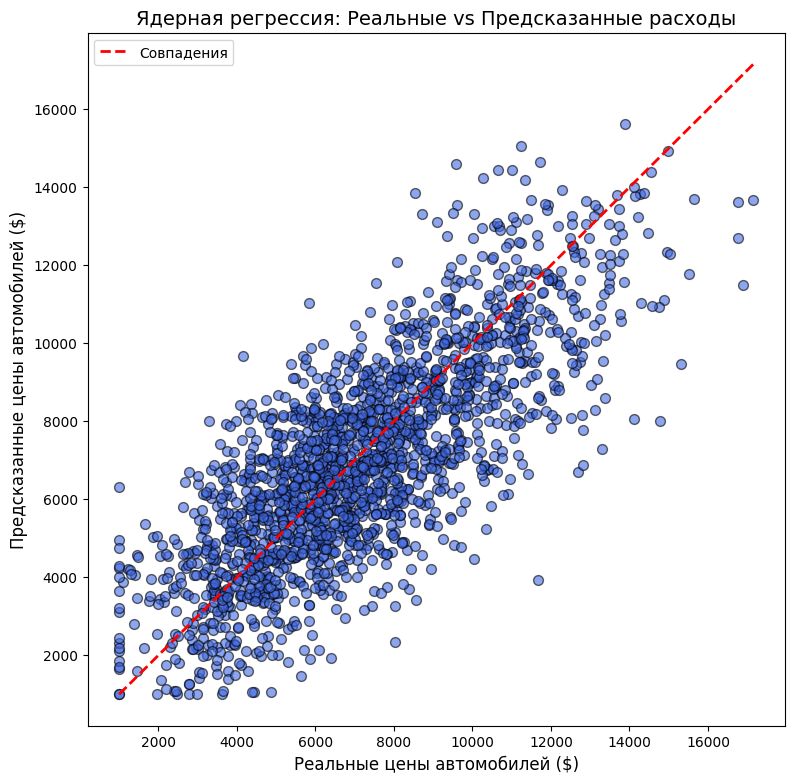

In [ ]:
plt.figure(figsize=(9,9))
plt.scatter(y_test, y_pred_nw, alpha=0.6, color='royalblue', edgecolors='k', s=50)

max_val = max(y_test.max(), y_pred_nw.max())
min_val = min(y_test.min(), y_pred_nw.min())

plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label="Совпадения")

plt.title('Ядерная регрессия: Реальные vs Предсказанные расходы', fontsize=14)
plt.xlabel('Реальные цены автомобилей ($)', fontsize=12)
plt.ylabel('Предсказанные цены автомобилей ($)', fontsize=12)
plt.legend()
plt.show()
# написать что использовалось
# Модель лучше всего предсказывает цены автомобилей в диапазоне от 4000 до 8000 ($)